In [1]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Shell import Shell
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import Pumps.ZX115.ZX115PumpFit as ZX115
import Pumps.Lauda.LaudaPumpFit as LAUDA
import numpy as np
import ht 
import pprint

Definimos el coil y el shell

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 5, pitch=12e-3)
print(coil.altura, coil.projected_d_out, coil.projected_d-2*coil.d_out)
shell = Shell(d_in = 80e-3, d_out=84e-3, lenght =95e-3, orientation=-90, material = "PVC", contain=coil)
shell.add_mass(0.051, 0.06)

0.06 0.06989728235927177 0.05084728235927177


Definimos el sistema

In [3]:
wfluxsys = PipingSystem()
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=7.5e-2, orientation=0, material="Plastic")) # Derecha
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro abajo
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=45e-3, orientation=-90, material="Plastic")) # Bajo
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_coil(coil)
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=45e-3, orientation=-90, material="Plastic")) # Bajo
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro izquierda
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=15e-2, orientation=0, material="Plastic")) # Izquierda
wfluxsys.add_singularity_loss(SingularityLoss(1)) # Cambio de diametro y cambio de dirección
wfluxsys.add_tube(Tube(d_in = 68e-3, d_out = 74e-3, lenght=68e-3, orientation=90, material="Plastic")) # Subo por el tanquesito
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=82e-3, orientation=90, material="Plastic")) # Subo por el tubo
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro a la derecha
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=7.5e-2, orientation=0, material="Plastic")) # Derecha
wfluxsys.conect() # Conecto

In [4]:
w_volume = wfluxsys.get_volume()

In [5]:
lfluxsys = PipingSystem()
lfluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
lfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
lfluxsys.add_shell(shell) # 
lfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
lfluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
lfluxsys.conect() # Conectar

Definimos el fluido

In [6]:
tw = 273.15 + 15
pw = 101325        
fluidow = 'Water'  
rhow = cp.PropsSI('D', 'T', tw, 'P', pw, "water")
muw = cp.PropsSI('V', 'T', tw, 'P', pw, "water") 
prw = cp.PropsSI('PRANDTL', 'T', tw, 'P', pw, "water")
kw = cp.PropsSI('CONDUCTIVITY', 'T', tw, 'P', pw, "water")
cpw = cp.PropsSI('CPMASS', 'T', tw, 'P', pw, "water")

In [7]:
tl = 273.15 + 0
pl = 101325        
mul = 0.0028 # Pa*s
rhol = 987.14 # kg/m3
cpl = 4180 * 1.04 # J /(kg K)
kl = 0.4984 # W/(m K)
prl = mul*cpl/kl
print(prl, kl)

24.42247191011236 0.4984


In [8]:
caudalw, _, _, _ = wfluxsys.cross_system_pump(rhow, muw, ZX115.Pa4m3s, Q_guess=1.2e-5, verbose=True, open = False);
caudall, _, _, _ = lfluxsys.cross_system_pump(rhol, mul, LAUDA.Pa4m3s, Q_guess=15e-5, verbose=True, open = False);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.107 L/min
 Caudal volumétrico      : 1.85e-05 m³/s
 Presión de cruce   :   5334.1 Pa
 Pérdida de altura  :    0.544 m.c.a.
═════════════════════════════════════════════


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :   10.404 L/min
 Caudal volumétrico      : 1.73e-04 m³/s
 Presión de cruce   :   8024.4 Pa
 Pérdida de altura  :    0.829 m.c.a.
═════════════════════════════════════════════



In [9]:
shell.re, shell.u, shell.d_hidraulico, shell.vol_in, coil.vol_out, shell.vol_in_free

(np.float64(434.7109216485373),
 np.float64(0.05095541177542685),
 0.024198559670781893,
 0.00047752208334564855,
 3.1669217443593606e-05,
 0.0003232836285222492)

In [10]:
m_dot_water = caudalw *rhow
m_dot_lauda = caudall *rhol

h_coil = coil.get_ht(pr=prw,pr_w=prw,mu=muw,mu_w=muw, k=kw)
h_shell = shell.get_ht(pr=prl,mu=mul,mu_w=mul, k=kl)
print(shell.ht_nu, )
k_coil = coil.conductivity 

UA = 1/(1/(h_coil*coil.area_in) + 1/(h_shell*coil.area_out) + np.log(coil.d_out/coil.d_in)/(coil.lenght*2*np.pi*k_coil))
print(UA)

th_in = 20 # 
tc_in = 0 # 

Cmin = ht.calc_Cmin(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
Cmax = ht.calc_Cmax(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
Cr = ht.calc_Cr(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
NTU = ht.NTU_from_UA(UA=UA, Cmin=Cmin)
print(NTU)
print(Cmin, Cmax)


33.68730805202887
12.085477659100693
0.15651136253351336
77.2178930875569 744.1035597797716


In [11]:
print(h_coil,h_shell,k_coil)

5937.961119925964 693.8327967264792 380.0


In [12]:
eff = ht.effectiveness_from_NTU(NTU = NTU, Cr=Cr, subtype= "crossflow, mixed Cmax")
print(eff*100)

14.379455400491882


In [13]:
Q_dot = eff*Cmin*(th_in - tc_in)
tc_out = tc_in + Q_dot/(m_dot_lauda*cpl)
th_out = th_in - Q_dot/(m_dot_water*cpw)

print(Q_dot, tc_out, th_out)


222.07024995449495 0.2984399779248737 17.124108919901623


In [14]:
print(shell.re)

434.7109216485373


0.00030124142906649983
16.325304364909293


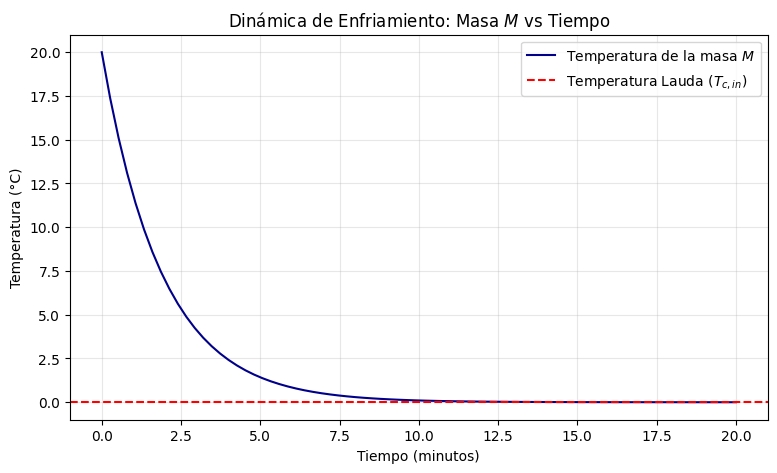

In [15]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def modelo_enfriamiento(t, T, eff, Cmin, M, cpm, tc_in):
    Q_dot = eff * Cmin * (T - tc_in)
    dTdt = -Q_dot / (M * cpm)
    return dTdt

paso_recirculacion = 16          # Segundos que tarda en dar la vuelta
tiempo_total = 600*2              # 1 hora en segundos (ajustado de 600 a 3600)
t_span = (0, tiempo_total)

# Creamos t_eval con pasos exactos de 16 segundos
# np.arange(inicio, fin + paso, paso) asegura que lleguemos al final
t_eval = np.arange(0, tiempo_total + paso_recirculacion, paso_recirculacion)
T0 = [20.0]
"""


t_span = (0, 600)    # 1 hora de simulación

t_eval = np.linspace(0, 600, 600) 
"""
sol = solve_ivp(
    modelo_enfriamiento, 
    t_span, 
    T0, 
    args=(eff, Cmin, w_volume*rhow, cpw, tc_in), 
    t_eval=t_eval
)
print(w_volume)
print(w_volume/caudalw)

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(sol.t / 60, sol.y[0], color='darkblue', label='Temperatura de la masa $M$')
plt.axhline(y=tc_in, color='red', linestyle='--', label='Temperatura Lauda ($T_{c,in}$)')
plt.title('Dinámica de Enfriamiento: Masa $M$ vs Tiempo')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()